# NHL Shot Outcome Prediction

## Research Question
Can the characteristics of an NHL shot predict whether the shot will result in a goal or be saved?

## Problem Definition
This project investigates whether the characteristics of an NHL shot can be used to predict whether the shot will result in a goal or be saved. The target variable is `goal`, where 1 represents a goal and 0 represents a saved shot.

This is a classification problem because the model predicts one of two possible outcomes.

A model like this could be useful for hockey analysts, coaches, scouts, and teams that want to better understand shot quality and the factors associated with scoring. Understanding which shot characteristics are connected to higher scoring chances can also help explain why some scoring opportunities are more dangerous than others.

## Project Focus
This project will examine NHL shot-level data from the 2025-2026 season to determine which shot characteristics are most related to whether a shot becomes a goal or is saved.

## Background and Context

In hockey analytics, shot quality refers to how likely a shot is to result in a goal based on the conditions surrounding the attempt. Rather than treating every shot equally, expected-goals models estimate the probability that an individual shot will become a goal (MoneyPuck, n.d.).

Several characteristics can influence shot quality. MoneyPuck's expected-goals model uses factors such as shot distance, shot angle, shot type, and events that occurred before the shot. Shots taken closer to the net and from more favorable angles generally represent more dangerous scoring opportunities (MoneyPuck, n.d.).

Shot-level hockey data has also been used to model goal outcomes using variables such as shot distance and angle (Yurko, 2023). Research has additionally examined factors such as shot location, game state, and information about events occurring before the shot when estimating scoring probability (Kierans, 2021).

This project uses a simpler set of these variables to investigate whether NHL shot characteristics can predict whether a shot results in a goal or is saved.

## Data Description

The dataset used in this project comes from MoneyPuck's publicly available NHL shot data for the 2025-2026 season. The original file contains 119,271 shot events and 124 attributes for each shot. MoneyPuck includes saved shots on goal, missed shots, and goals, along with information such as shot distance, shot angle, player position, and other shot context variables (MoneyPuck, n.d.).

Each row represents one NHL shot event.

The target variable for this project is `goal`, where 1 represents a goal and 0 represents a saved shot.

Potential predictor variables include shot distance, shot angle, shot type, period, player position, rebound status, rush status, and empty-net status.

For this project, I filtered the dataset to include only goals and saved shots because the research question compares those two outcomes. Missed shots were removed because they did not result in a save or goal. Empty-net shots were also removed because there is usually no goalie present to make a save.

One limitation of the dataset is that it does not directly include every factor that may influence shot quality, such as defensive pressure, screens, exact goalie positioning, or detailed player skill.


## Planned Models
- Logistic Regression
- Decision Tree Classifier

## Target Variable
- Goal = 1
- Saved Shot = 0

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Loading the Data

The dataset contains NHL shot-level data from the 2025-2026 season.  
I will first load the dataset and inspect its structure before selecting the variables needed for the project.

In [2]:
shots = pd.read_csv("data/shots_2025.csv")

shots.head()

,shotID,arenaAdjustedShotDistance,arenaAdjustedXCord,arenaAdjustedXCordABS,arenaAdjustedYCord,arenaAdjustedYCordAbs,averageRestDifference,awayEmptyNet,awayPenalty1Length,awayPenalty1TimeLeft,...,xCordAdjusted,xFroze,xGoal,xPlayContinuedInZone,xPlayContinuedOutsideZone,xPlayStopped,xRebound,xShotWasOnGoal,yCord,yCordAdjusted
0,0,38.0,-58.0,58.0,-22.0,22.0,0.0,0,0,0,...,58,0.308458,0.017510,0.350448,0.253295,0.035563,0.034727,0.791506,-22,22
1,1,59.0,-33.0,33.0,-19.0,19.0,0.0,0,0,0,...,33,0.304403,0.036720,0.356975,0.235788,0.025301,0.040814,0.738728,-19,19
2,2,45.0,55.0,55.0,-29.0,29.0,0.0,0,0,0,...,55,0.306225,0.016030,0.358237,0.263372,0.026669,0.029466,0.831215,-29,-29
3,3,63.0,35.0,35.0,33.0,33.0,0.0,0,0,0,...,35,0.200191,0.009735,0.439703,0.294931,0.020398,0.035042,0.659939,33,33
4,4,68.0,30.0,30.0,-34.0,34.0,0.0,0,0,0,...,30,0.219360,0.009977,0.422430,0.307621,0.020837,0.019774,0.681355,-34,-34


## Exploring the Dataset

Before cleaning or selecting features, I first examined the size and structure of the dataset. This helps me understand how many observations and variables are available and what types of data I am working with.

In [4]:
shots.shape

(119271, 124)

In [5]:
shots.info()

<class 'pandas.DataFrame'>
RangeIndex: 119271 entries, 0 to 119270
Columns: 124 entries, shotID to yCordAdjusted
dtypes: float64(34), int64(77), str(13)
memory usage: 120.4 MB


## Selecting Relevant Variables

The full dataset contains 124 columns, but many of them are not needed for this project. I will focus on variables that describe the shot itself, the game situation, and whether the shot resulted in a goal.

In [6]:
selected_columns = [
    "event",
    "goal",
    "shotDistance",
    "shotAngle",
    "shotType",
    "period",
    "playerPositionThatDidEvent",
    "shotRebound",
    "shotRush",
    "shotOnEmptyNet"
]

shots_selected = shots[selected_columns]

shots_selected.head()

,event,goal,shotDistance,shotAngle,shotType,period,playerPositionThatDidEvent,shotRebound,shotRush,shotOnEmptyNet
0,SHOT,0,38.013156,35.362462,WRIST,1,C,0,0,0
1,SHOT,0,59.135438,18.741340,SLAP,1,D,0,0,0
2,MISS,0,44.687806,-40.462227,SNAP,1,C,0,0,0
3,SHOT,0,63.285069,31.429566,SNAP,1,D,0,0,0
4,SHOT,0,68.095521,-29.953608,SNAP,1,D,0,0,0


## Shot Outcomes

The dataset includes goals, shots on goal that were saved, and missed shots. Since my research question focuses on whether a shot results in a goal or is saved, I first examined how many observations belong to each outcome.

In [7]:
shots_selected["event"].value_counts()

event
SHOT    68896
MISS    41810
GOAL     8565
Name: count, dtype: int64

## Filtering to Goals and Saved Shots

My research question compares shots that result in goals with shots that are saved. Because missed shots do not reach the goalie, I removed all rows labeled `MISS` and kept only `GOAL` and `SHOT` events.

In [8]:
goal_save_shots = shots_selected[
    shots_selected["event"].isin(["GOAL", "SHOT"])
].copy()

goal_save_shots["event"].value_counts()

event
SHOT    68896
GOAL     8565
Name: count, dtype: int64

## Checking the Target Variable

The target variable for this project is whether a shot resulted in a goal. In the dataset, `goal = 1` represents a goal and `goal = 0` represents a saved shot. I checked the distribution to see how common each outcome is.

In [12]:
goal_save_shots["goal"].value_counts()

goal
0    68896
1     8565
Name: count, dtype: int64

In [11]:
goal_save_shots["goal"].value_counts(normalize=True)

goal
0    0.889428
1    0.110572
Name: proportion, dtype: float64

## Checking for Missing Values

Before modeling, I checked the selected variables for missing values. Any missing data may need to be removed or handled before training the models.

In [13]:
goal_save_shots.isnull().sum()

event                           0
goal                            0
shotDistance                    0
shotAngle                       0
shotType                      770
period                          0
playerPositionThatDidEvent    478
shotRebound                     0
shotRush                        0
shotOnEmptyNet                  0
dtype: int64

## Handling Missing Values

Only `shotType` and `playerPositionThatDidEvent` contain missing values. Since the number of missing observations is small compared with the size of the dataset, I removed rows with missing values in these variables.

In [14]:
goal_save_shots = goal_save_shots.dropna(
    subset=["shotType", "playerPositionThatDidEvent"]
)

goal_save_shots.isnull().sum()

event                         0
goal                          0
shotDistance                  0
shotAngle                     0
shotType                      0
period                        0
playerPositionThatDidEvent    0
shotRebound                   0
shotRush                      0
shotOnEmptyNet                0
dtype: int64

## Exploring Categorical Features

Before converting categorical variables into a format the models can use, I examined the unique values in `shotType` and `playerPositionThatDidEvent`.

In [15]:
print(goal_save_shots["shotType"].value_counts())

shotType
WRIST    34571
SNAP     20186
SLAP      8116
BACK      5783
TIP       5715
DEFL      1395
WRAP       457
Name: count, dtype: int64


In [16]:
print(goal_save_shots["playerPositionThatDidEvent"].value_counts())

playerPositionThatDidEvent
C    26019
D    21211
R    14748
L    14234
G       11
Name: count, dtype: int64


## Removing Rare Shooter Positions

The shooter-position variable contains centers (`C`), defensemen (`D`), right wings (`R`), left wings (`L`), and a very small number of goalies (`G`). Since only 11 observations were recorded for goalies, I removed those rows because they are not representative of typical NHL shooting situations.

In [17]:
goal_save_shots = goal_save_shots[
    goal_save_shots["playerPositionThatDidEvent"] != "G"
].copy()

goal_save_shots["playerPositionThatDidEvent"].value_counts()

playerPositionThatDidEvent
C    26019
D    21211
R    14748
L    14234
Name: count, dtype: int64

## Exploring Numeric Features

I examined the numeric shot variables to understand their ranges and identify any unusual values before modeling.

In [18]:
goal_save_shots[
    ["shotDistance", "shotAngle", "period", "shotRebound", "shotRush", "shotOnEmptyNet"]
].describe()

,shotDistance,shotAngle,period,shotRebound,shotRush,shotOnEmptyNet
count,76212.000000,76212.000000,76212.000000,76212.000000,76212.000000,76212.000000
mean,33.185068,-0.086478,2.028736,0.077612,0.000617,0.006548
std,20.000015,38.271114,0.842376,0.267563,0.024826,0.080652
min,1.000000,-88.408860,1.000000,0.000000,0.000000,0.000000
25%,15.620499,-30.963757,1.000000,0.000000,0.000000,0.000000
50%,31.953091,0.000000,2.000000,0.000000,0.000000,0.000000
75%,46.486557,30.963757,3.000000,0.000000,0.000000,0.000000
max,97.989795,88.408860,5.000000,1.000000,1.000000,1.000000


## Visualizing Shot Outcomes

To better understand the relationship between shot characteristics and scoring, I created visualizations comparing goals and saved shots.

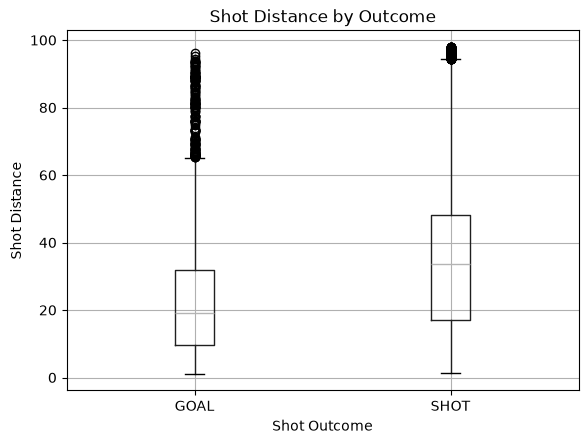

In [19]:
goal_save_shots.boxplot(
    column="shotDistance",
    by="event"
)

plt.title("Shot Distance by Outcome")
plt.suptitle("")
plt.xlabel("Shot Outcome")
plt.ylabel("Shot Distance")
plt.show()

### Shot Distance Observation

Goals generally occur from shorter distances than saved shots. The median shot distance for goals is noticeably lower, suggesting that shot distance may be an important predictor of whether a shot results in a goal.

In [20]:
goal_save_shots["absoluteShotAngle"] = goal_save_shots["shotAngle"].abs()

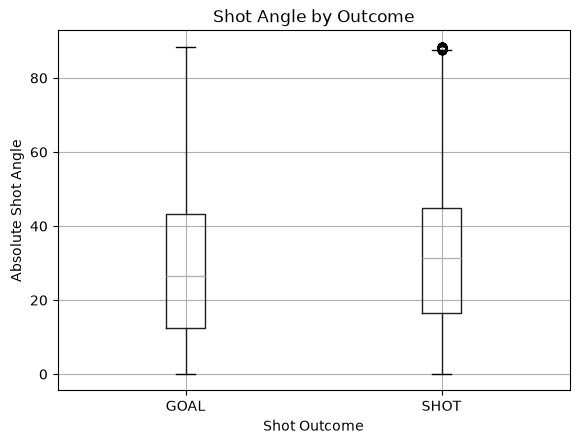

In [21]:
goal_save_shots.boxplot(
    column="absoluteShotAngle",
    by="event"
)

plt.title("Shot Angle by Outcome")
plt.suptitle("")
plt.xlabel("Shot Outcome")
plt.ylabel("Absolute Shot Angle")
plt.show()

### Shot Angle Observation

Goals tend to come from slightly smaller absolute shot angles than saved shots, meaning they are generally taken from more central locations. However, the two distributions overlap considerably, so shot angle may be a weaker predictor than shot distance.

In [22]:
shot_type_summary = (
    goal_save_shots
    .groupby("shotType")["goal"]
    .mean()
    .sort_values(ascending=False)
)

shot_type_summary

shotType
DEFL     0.158423
TIP      0.133532
BACK     0.127788
SNAP     0.121383
WRIST    0.099210
SLAP     0.083662
WRAP     0.072210
Name: goal, dtype: float64

### Shot Type Observation

Goal rates vary by shot type. Deflections and tips have the highest scoring rates, while slap shots and wraparound attempts have lower scoring rates. This suggests that shot type may be an important predictor of whether a shot results in a goal.

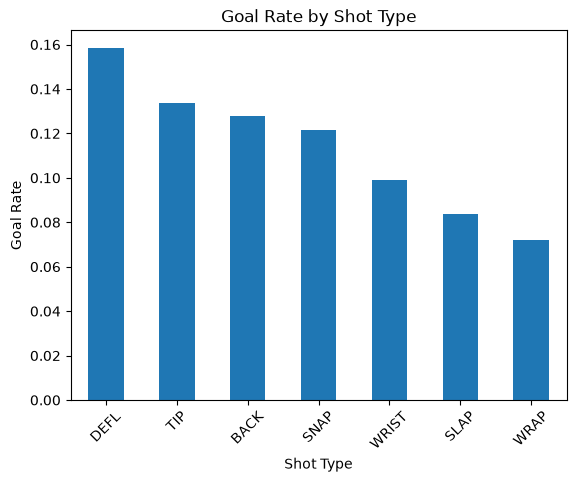

In [23]:
shot_type_summary.plot(kind="bar")

plt.title("Goal Rate by Shot Type")
plt.xlabel("Shot Type")
plt.ylabel("Goal Rate")
plt.xticks(rotation=45)
plt.show()

## Rebound Shots

Rebound opportunities may be more dangerous because the goalie can be out of position after making the first save. I compared the goal rate of rebound shots with non-rebound shots.

In [24]:
rebound_summary = (
    goal_save_shots
    .groupby("shotRebound")["goal"]
    .mean()
)

rebound_summary

shotRebound
0    0.104428
1    0.164497
Name: goal, dtype: float64

### Rebound Shot Observation

Rebound shots have a higher goal rate than non-rebound shots. This suggests that rebound status may be an important predictor because goalies can be more vulnerable immediately after making an initial save.

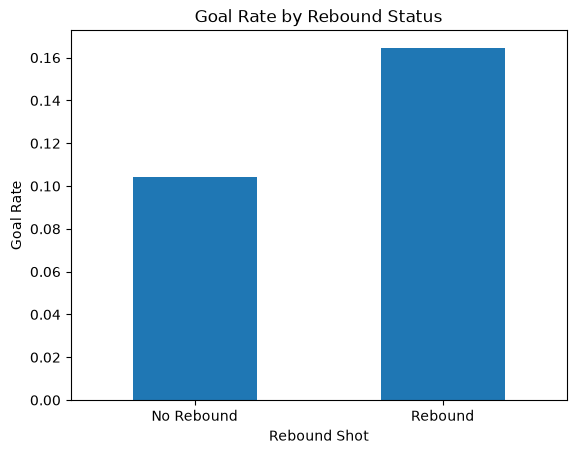

In [25]:
rebound_summary.plot(kind="bar")

plt.title("Goal Rate by Rebound Status")
plt.xlabel("Rebound Shot")
plt.ylabel("Goal Rate")
plt.xticks([0, 1], ["No Rebound", "Rebound"], rotation=0)
plt.show()

## Rush Shots

Shots taken during rush situations may have different scoring chances because the defense and goalie can have less time to get set. I compared the goal rate of rush shots with non-rush shots.

In [26]:
rush_summary = (
    goal_save_shots
    .groupby("shotRush")["goal"]
    .mean()
)

rush_summary

shotRush
0    0.109040
1    0.191489
Name: goal, dtype: float64

### Rush Shot Observation

Rush shots have a noticeably higher goal rate than non-rush shots. This suggests that rush situations may create more dangerous scoring opportunities because the goalie and defense have less time to get set. Rush shots have a noticeably higher goal rate than non-rush shots. This suggests that rush situations may create more dangerous scoring opportunities because the goalie and defense have less time to get set. However, rush shots make up a relatively small portion of the dataset, so this result should be interpreted cautiously.

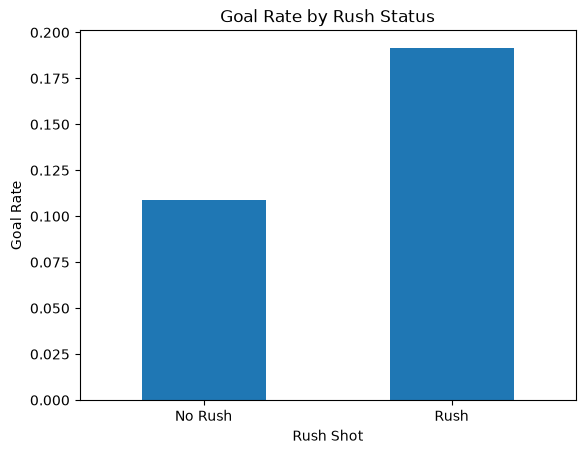

In [27]:
rush_summary.plot(kind="bar")

plt.title("Goal Rate by Rush Status")
plt.xlabel("Rush Shot")
plt.ylabel("Goal Rate")
plt.xticks([0, 1], ["No Rush", "Rush"], rotation=0)
plt.show()

## Empty-Net Shots

Empty-net attempts are different from normal shots because there may be no goalie defending the net. I examined their goal rate separately to decide whether they should remain in the modeling dataset.

In [29]:
empty_net_summary = (
    goal_save_shots
    .groupby("shotOnEmptyNet")["goal"]
    .mean()
)

empty_net_summary

shotOnEmptyNet
0    0.103258
1    0.993988
Name: goal, dtype: float64

### Empty-Net Shot Observation

Empty-net shots have an extremely high goal rate compared with normal shots. Because my research question focuses on whether a shot results in a goal or is saved by a goalie, I removed empty-net attempts from the modeling dataset.

In [30]:
goal_save_shots = goal_save_shots[
    goal_save_shots["shotOnEmptyNet"] == 0
].copy()

goal_save_shots.shape

(75713, 11)

## Final Target Distribution

After removing empty-net shots, I checked the goal and save distribution again to understand the class balance of the final modeling dataset.

In [31]:
goal_save_shots["goal"].value_counts()

goal
0    67895
1     7818
Name: count, dtype: int64

In [32]:
goal_save_shots["goal"].value_counts(normalize=True)

goal
0    0.896742
1    0.103258
Name: proportion, dtype: float64

### Target Distribution Observation

After removing empty-net shots, about 89.7% of observations are saved shots and 10.3% are goals. This class imbalance will be important when evaluating the models, so I will use more than accuracy alone to judge performance.

## Goal Rate by Player Position

Different player positions may take different types of shots and shoot from different areas of the ice. I compared goal rates by player position to see whether position may help predict shot outcomes.

In [33]:
position_summary = (
    goal_save_shots
    .groupby("playerPositionThatDidEvent")["goal"]
    .mean()
    .sort_values(ascending=False)
)

position_summary

playerPositionThatDidEvent
R    0.122728
L    0.122088
C    0.118500
D    0.058671
Name: goal, dtype: float64

### Player Position Observation

Forwards have similar goal rates, while defensemen have a noticeably lower goal rate. This suggests that player position may be useful for predicting shot outcomes.

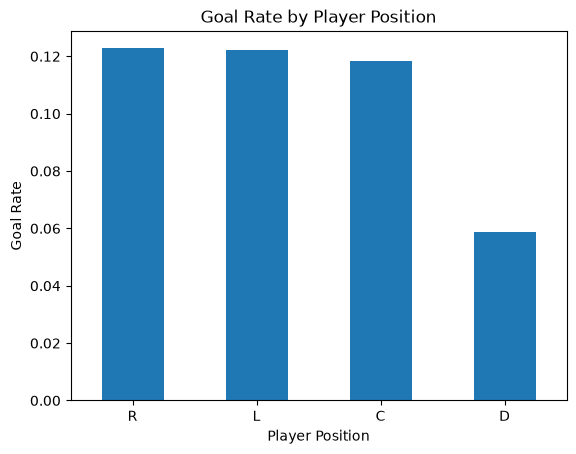

In [34]:
position_summary.plot(kind="bar")

plt.title("Goal Rate by Player Position")
plt.xlabel("Player Position")
plt.ylabel("Goal Rate")
plt.xticks(rotation=0)
plt.show()

## Goal Rate by Period

Scoring chances may change throughout the game because of fatigue, game strategy, and overtime situations. I compared goal rates across periods to see whether the period of the game may help predict shot outcomes.

In [35]:
period_summary = (
    goal_save_shots
    .groupby("period")["goal"]
    .mean()
)

period_summary

period
1    0.098723
2    0.106978
3    0.100634
4    0.156934
5    0.117647
Name: goal, dtype: float64

### Period Observation

Goal rates are fairly similar during the first three periods. Overtime periods show somewhat higher goal rates, although these periods contain fewer observations, so the differences should be interpreted cautiously.

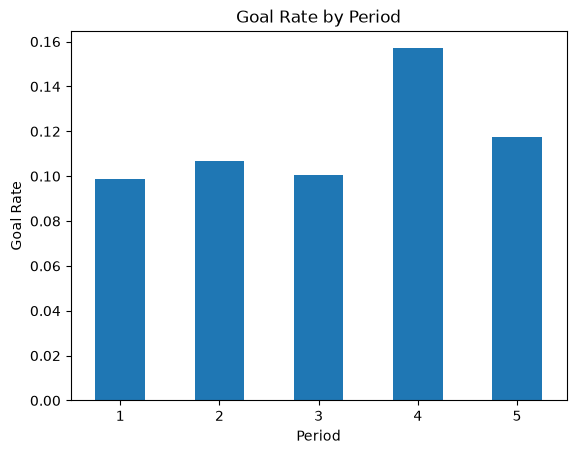

In [36]:
period_summary.plot(kind="bar")

plt.title("Goal Rate by Period")
plt.xlabel("Period")
plt.ylabel("Goal Rate")
plt.xticks(rotation=0)
plt.show()

## Data Preparation and Feature Selection

Before training the models, I cleaned the data and selected features that were directly related to shot quality.

I removed missed shots because the project compares goals with saved shots. I also removed empty-net shots because there is usually no goalie present to make a save. Rows with missing values in `shotType` or `playerPositionThatDidEvent` were removed because the number of missing observations was small compared with the full dataset.

The final features selected were:

- `shotDistance`
- `absoluteShotAngle`
- `shotType`
- `period`
- `playerPositionThatDidEvent`
- `shotRebound`
- `shotRush`

These features were selected because the exploratory analysis showed meaningful relationships with goal outcomes, especially shot distance and shot angle.

Categorical variables such as shot type and player position were converted into numeric indicator variables using one-hot encoding so they could be used by the machine-learning models.

To reduce data leakage, I excluded variables that directly describe the shot outcome or contain information that would only be known after the shot occurred. The target variable `goal` was kept separate from the predictor variables.

I also reviewed the numeric feature ranges for unusual values. Shot distance and shot angle remained within reasonable hockey ranges, so I did not remove additional observations as outliers.

## Preparing Features for Modeling

Before training the models, I separated the predictor variables from the target variable. I will use shot location, shot type, player position, period, rebound status, and rush status to predict whether a shot results in a goal.

In [37]:
features = [
    "shotDistance",
    "absoluteShotAngle",
    "shotType",
    "period",
    "playerPositionThatDidEvent",
    "shotRebound",
    "shotRush"
]

X = goal_save_shots[features]
y = goal_save_shots["goal"]

## Encoding Categorical Variables

The models cannot directly use text categories such as shot type or player position. I converted these categorical variables into numeric indicator columns using one-hot encoding.

In [38]:
X_encoded = pd.get_dummies(
    X,
    columns=["shotType", "playerPositionThatDidEvent"],
    drop_first=True
)

X_encoded.head()

,shotDistance,absoluteShotAngle,period,shotRebound,shotRush,shotType_DEFL,shotType_SLAP,shotType_SNAP,shotType_TIP,shotType_WRAP,shotType_WRIST,playerPositionThatDidEvent_D,playerPositionThatDidEvent_L,playerPositionThatDidEvent_R
0,38.013156,35.362462,1,0,0,False,False,False,False,False,True,False,False,False
1,59.135438,18.741340,1,0,0,False,True,False,False,False,False,True,False,False
3,63.285069,31.429566,1,0,0,False,False,True,False,False,False,True,False,False
4,68.095521,29.953608,1,0,0,False,False,True,False,False,False,True,False,False
5,41.773197,42.089162,1,0,0,False,True,False,False,False,False,True,False,False


In [39]:
X_encoded.shape

(75713, 14)

## Training and Testing Split

I split the dataset into training and testing sets so the models can be trained on one portion of the data and evaluated on observations they have not seen before. I used a stratified split to preserve the proportion of goals and saved shots in both sets.

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [41]:
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (60570, 14)
Testing set: (15143, 14)


## Baseline Model

Because saved shots make up most of the dataset, a simple baseline is to predict every shot as a save. This gives me a minimum performance level that the machine-learning models should improve on.

In [42]:
baseline_accuracy = y_test.value_counts(normalize=True).max()

print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 0.896717955490986


## Evaluation Metrics

Because the dataset is imbalanced, accuracy alone is not enough to judge model performance. I used several evaluation metrics:

- **Accuracy:** the percentage of all predictions that were correct.
- **Precision:** among the shots predicted as goals, the percentage that were actually goals.
- **Recall:** among all actual goals, the percentage that the model correctly identified.
- **F1-score:** a balance between precision and recall.

For this project, recall and F1-score are especially important because goals are much less common than saved shots.

## Logistic Regression Model

I first trained a Logistic Regression model. This model is appropriate because the target variable has two possible outcomes: goal or saved shot.

In [43]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

## Evaluating Logistic Regression

After training the Logistic Regression model, I used the testing set to evaluate how well it predicts goals and saved shots. Because the dataset is imbalanced, I looked at precision, recall, and F1-score in addition to accuracy.

In [44]:
from sklearn.metrics import accuracy_score, classification_report

log_predictions = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, log_predictions))
print()
print(classification_report(y_test, log_predictions))

Accuracy: 0.896717955490986

              precision    recall  f1-score   support

           0       0.90      1.00      0.95     13579
           1       0.00      0.00      0.00      1564

    accuracy                           0.90     15143
   macro avg       0.45      0.50      0.47     15143
weighted avg       0.80      0.90      0.85     15143



c:\Users\natem\OneDrive\Documents\Coding Projects\DTSC Studio 2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\natem\OneDrive\Documents\Coding Projects\DTSC Studio 2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\natem\OneDrive\Documents\Coding Projects\DTSC Studio 2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parame

### Logistic Regression Observation

Although the Logistic Regression model achieved about 89.7% accuracy, this is the same as the baseline model. The classification report shows that the model predicted all observations as saved shots and failed to correctly identify any goals. This happens because the dataset is heavily imbalanced, with far more saved shots than goals.

Because of this, accuracy alone is not a good measure of model performance for this project.

In [45]:
balanced_log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

balanced_log_model.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to

In [46]:
balanced_log_predictions = balanced_log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, balanced_log_predictions))
print()
print(classification_report(y_test, balanced_log_predictions))

Accuracy: 0.6414845142970349

              precision    recall  f1-score   support

           0       0.95      0.63      0.76     13579
           1       0.18      0.72      0.29      1564

    accuracy                           0.64     15143
   macro avg       0.57      0.67      0.53     15143
weighted avg       0.87      0.64      0.71     15143



### Balanced Logistic Regression Observation

Balancing the classes caused overall accuracy to decrease, but the model became much better at identifying actual goals. The recall for goals increased to 72%, meaning the model correctly identified a large portion of the goals in the test set.

However, precision for goals was only 18%, meaning many shots predicted as goals were actually saved. This shows an important tradeoff between detecting more goals and producing more false positive predictions.

## Decision Tree Classifier

The second model I used was a Decision Tree Classifier. A decision tree can capture nonlinear relationships by splitting the data into groups based on feature values such as shot distance, shot angle, and shot type. To keep the Decision Tree interpretable and reduce overfitting, I limited the tree to a maximum depth of 5. A deeper tree could fit the training data more closely, but it would also become harder to explain and could perform worse on new data.

In [47]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

tree_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_feat

## Evaluating the Decision Tree

I evaluated the Decision Tree using the same test set and the same metrics as the Logistic Regression model so the results could be compared fairly.

In [48]:
tree_predictions = tree_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, tree_predictions))
print()
print(classification_report(y_test, tree_predictions))

Accuracy: 0.5517400779237932

              precision    recall  f1-score   support

           0       0.96      0.52      0.68     13579
           1       0.16      0.81      0.27      1564

    accuracy                           0.55     15143
   macro avg       0.56      0.67      0.47     15143
weighted avg       0.88      0.55      0.63     15143



### Decision Tree Observation

The Decision Tree identified 81% of the actual goals, which was higher than the Logistic Regression model. However, its overall accuracy was lower at about 55%, and its goal precision was only 16%.

Compared with Logistic Regression, the Decision Tree was more aggressive at predicting goals. This helped it find more true goals, but it also created more false positive predictions.

## Model Comparison

I compared the balanced Logistic Regression and Decision Tree models using accuracy, precision, recall, and F1-score for the goal class.

In [49]:
from sklearn.metrics import precision_score, recall_score, f1_score

model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, balanced_log_predictions),
        accuracy_score(y_test, tree_predictions)
    ],
    "Goal Precision": [
        precision_score(y_test, balanced_log_predictions),
        precision_score(y_test, tree_predictions)
    ],
    "Goal Recall": [
        recall_score(y_test, balanced_log_predictions),
        recall_score(y_test, tree_predictions)
    ],
    "Goal F1": [
        f1_score(y_test, balanced_log_predictions),
        f1_score(y_test, tree_predictions)
    ]
})

model_comparison

,Model,Accuracy,Goal Precision,Goal Recall,Goal F1
0,Logistic Regression,0.641485,0.183456,0.716113,0.292085
1,Decision Tree,0.551740,0.163489,0.811381,0.272142


### Model Comparison Observation

The balanced Logistic Regression model performed better overall than the Decision Tree. It had higher accuracy, goal precision, and goal F1-score. The Decision Tree had higher recall, meaning it identified more of the actual goals, but it also produced more false positives.

Based on these results, I would select the balanced Logistic Regression as the final model because it provides a better overall balance between correctly identifying goals and avoiding incorrect goal predictions.

### Comparison to the Baseline

The baseline model achieved about 89.7% accuracy by predicting every shot as a save. Although this accuracy is higher than the balanced Logistic Regression and Decision Tree models, the baseline is not useful for identifying goals because it never predicts the minority class.

The balanced Logistic Regression and Decision Tree both sacrificed overall accuracy in order to identify actual goals. The Logistic Regression provided the better overall balance between goal recall, precision, and F1-score, while the Decision Tree identified more goals but produced more false positives.

## Confusion Matrix

To better understand the model's predictions, I created a confusion matrix. This shows how many saved shots and goals were predicted correctly and incorrectly.

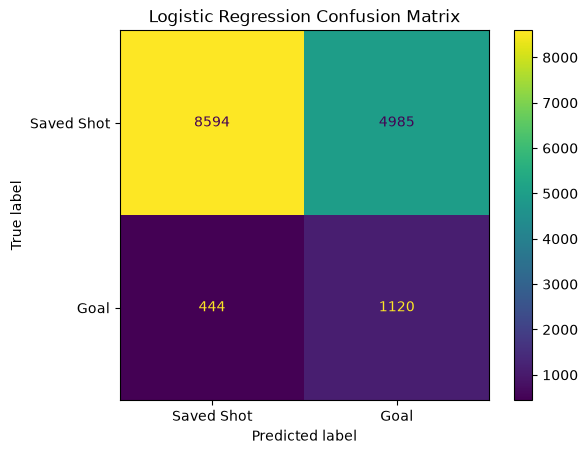

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, balanced_log_predictions)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Saved Shot", "Goal"]
)

display.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

### Confusion Matrix Observation

The balanced Logistic Regression correctly identified 1,120 goals and 8,594 saved shots. It missed 444 goals, but it also predicted 4,985 saved shots as goals.

This shows that the model is much better at finding actual goals than the original unbalanced model, but it does so by accepting a larger number of false positive goal predictions.

## Interpreting Logistic Regression Coefficients

Logistic Regression assigns a coefficient to each feature. Positive coefficients push the prediction more toward a goal, while negative coefficients push the prediction more toward a saved shot.

In [51]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": balanced_log_model.coef_[0]
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient
6,shotType_SLAP,1.167971
7,shotType_SNAP,0.841800
10,shotType_WRIST,0.498461
5,shotType_DEFL,0.056104
13,playerPositionThatDidEvent_R,0.048437
11,playerPositionThatDidEvent_D,0.032360
2,period,0.026481
12,playerPositionThatDidEvent_L,0.019152
4,shotRush,0.017202
1,absoluteShotAngle,-0.016882


### Logistic Regression Coefficient Observation

The coefficients show how each feature affects the model's prediction while holding the other features constant. Positive coefficients increase the predicted likelihood of a goal, while negative coefficients decrease it.

Shot distance and absolute shot angle both have negative coefficients, meaning shots taken farther from the net or from wider angles are less likely to be predicted as goals. Some shot types also have noticeably different effects after accounting for shot location and the other variables.

These coefficients should not be treated as a direct ranking of feature importance because the features are measured on different scales and categorical variables are compared with reference categories.

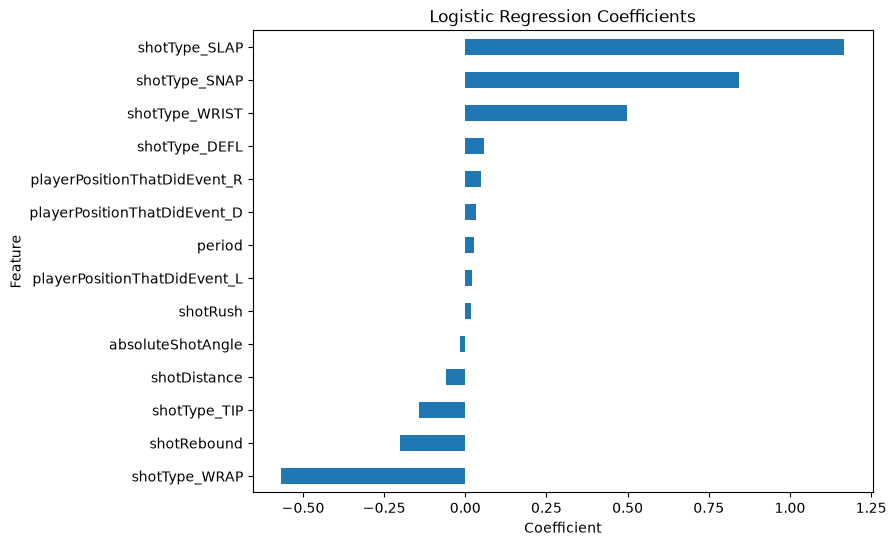

In [52]:
coefficients_sorted = coefficients.sort_values("Coefficient")

coefficients_sorted.plot(
    x="Feature",
    y="Coefficient",
    kind="barh",
    legend=False,
    figsize=(8, 6)
)

plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

### Coefficient Interpretation

The model suggests that shot distance and wider shot angles reduce the likelihood of a goal. Some shot types increase the predicted probability of scoring, while others decrease it relative to the reference shot type.

Because these coefficients are affected by the scale of each variable and by the reference categories used during one-hot encoding, they are best interpreted as directional effects rather than a perfect ranking of importance.

## Decision Tree Feature Importance

The Decision Tree also provides feature importance values. These values show which variables the tree relied on most when making its predictions.

In [54]:
tree_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": tree_model.feature_importances_
})

tree_importance = tree_importance.sort_values(
    by="Importance",
    ascending=False
)

tree_importance

,Feature,Importance
0,shotDistance,0.803084
1,absoluteShotAngle,0.149225
6,shotType_SLAP,0.021468
7,shotType_SNAP,0.017956
9,shotType_WRAP,0.003958
2,period,0.002211
3,shotRebound,0.001538
12,playerPositionThatDidEvent_L,0.000561
5,shotType_DEFL,0.000000
4,shotRush,0.000000


### Decision Tree Feature Importance Observation

The Decision Tree relied most heavily on shot distance, followed by absolute shot angle. Shot type had a smaller influence, while several other variables were not used in the final tree.

Because the tree was limited to a maximum depth of 5, some features received an importance of zero simply because the model did not use them in its splits.

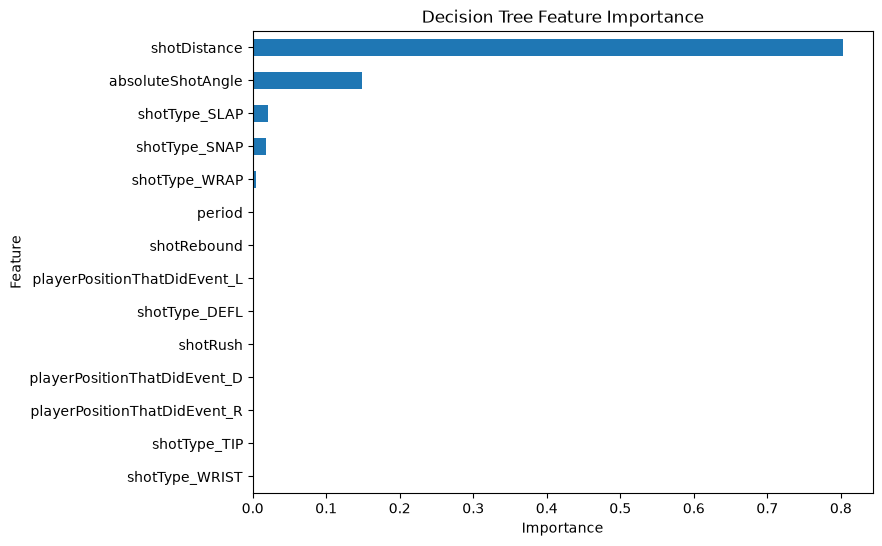

In [55]:
tree_importance_sorted = tree_importance.sort_values("Importance")

tree_importance_sorted.plot(
    x="Feature",
    y="Importance",
    kind="barh",
    legend=False,
    figsize=(8, 6)
)

plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

### Feature Importance Interpretation

The Decision Tree shows that shot distance is by far the most important feature, followed by absolute shot angle. This suggests that shot location is the strongest factor in determining whether a shot becomes a goal or is saved. Other features, such as shot type and period, contributed much less to the tree's predictions.

## Limitations and Ethics

This model has several limitations. First, the dataset is highly imbalanced because goals occur much less often than saved shots. This makes prediction difficult and means accuracy alone can be misleading.

The model also only uses a limited set of shot characteristics. It does not directly account for factors such as goalie skill, defensive pressure, screen traffic, passing sequences, or exact player ability. These missing variables may affect whether a shot becomes a goal.

There is also a tradeoff between false positives and false negatives. A false positive occurs when the model predicts a goal but the shot is actually saved. A false negative occurs when the model predicts a save but the shot actually becomes a goal.

Another possible source of bias is that the dataset may not represent every player, team, goalie, or game situation equally. Some players take many more shots than others, and different teams may create different types of scoring chances. Because of this, the model may work better for some situations than others.

Incorrect predictions could affect analysts, coaches, or scouts if the model were used to judge shot quality or player performance. For example, consistently overestimating or underestimating certain types of shots could lead to misleading conclusions about players or scoring opportunities.

In a real-world hockey setting, this model could be useful for understanding shot quality, but it should not be used as the only factor for evaluating players or making coaching decisions.

## Conclusion

This project examined whether NHL shot characteristics can predict whether a shot results in a goal or is saved. I compared a balanced Logistic Regression model with a Decision Tree Classifier.

The balanced Logistic Regression performed better overall because it had higher accuracy, precision, and F1-score for goals, while still identifying a large portion of actual goals. The Decision Tree had higher recall, but it also produced more false positive goal predictions.

The analysis showed that shot distance and shot angle were especially important. Shots taken closer to the net and from more central angles were more likely to result in goals. Shot type, rebound situations, rush situations, and player position also showed meaningful differences in scoring rates.

Overall, the models were able to identify useful patterns in NHL shot data, but the class imbalance and missing contextual factors limit how accurate the predictions can be.

## References

Kierans, J. (2021). *Isolation of latent player shooting ability in the National Hockey League* [Master's thesis, Concordia University].  
https://spectrum.library.concordia.ca/id/eprint/988845/

MoneyPuck. (n.d.). *About and how it works: Expected goals model*. MoneyPuck.  
https://www.moneypuck.com/about.htm

MoneyPuck. (n.d.). *Download data*. MoneyPuck.  
https://moneypuck.com/data.htm

Yurko, R. (2023). *National Hockey League shots*. SCORE Sports Data Repository.

https://data.scorenetwork.org/

## Future Improvements

In the future, this project could be improved by adding more contextual features such as goalie performance, passing sequences, defensive pressure, player shooting ability, and game strength situations. More advanced models could also be tested to determine whether they improve goal prediction without making the model too difficult to interpret.

## AI Usage Disclosure

I used ChatGPT (OpenAI, GPT-5.6) to help brainstorm the project structure, explain machine-learning concepts, review code, troubleshoot errors, and improve the clarity of written explanations.

I made the final decisions about the research question, selected features, data-cleaning choices, model selection, evaluation, and interpretation of results. I also reviewed and ran all code used in the project.